# Шаг 3

## Импорты библиотек и функций из прошлых шагов

In [26]:
import networkx as nx
import random
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import numpy as np
import base64
from IPython.display import display, HTML
import ipynbname
from pathlib import Path
from pyvis.network import Network
import json
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import random
import networkx.algorithms.isomorphism as iso
import time
import collections


def get_full_graphlet_library():
    lib = []
    # 2 вершины
    lib.append(nx.path_graph(2)) 
    # 3 вершины
    lib.append(nx.path_graph(3))
    lib.append(nx.complete_graph(3))
    # 4 вершины
    lib.append(nx.path_graph(4))
    lib.append(nx.cycle_graph(4))
    lib.append(nx.star_graph(3))
    lib.append(nx.complete_graph(4))
    
    # Pan (Лапка)
    G_pan = nx.Graph([(0,1), (1,2), (2,0), (2,3)])
    lib.append(G_pan)
    
    # Diamond (Ромб с перемычкой)
    G_diamond = nx.Graph([(0,1), (1,2), (2,3), (3,0), (1,3)])
    lib.append(G_diamond)
    
    return lib

FULL_LIBRARY = get_full_graphlet_library()

def show_html_file(filename):
    try:
        with open(filename, "rb") as f:
            html_content = f.read()
            
        b64_content = base64.b64encode(html_content).decode('utf-8')
        data_url = f'data:text/html;charset=utf-8;base64,{b64_content}'
        iframe = f'<iframe src="{data_url}" width="100%" height="650px" style="border: 1px solid #ddd; border-radius: 5px;"></iframe>'
        
        display(HTML(iframe))
        
    except FileNotFoundError:
        print(f"Файл {filename} не найден. Проверьте путь.")

In [27]:
def visualize_step(G, step_num, info_text):
    """Применяет стили и сохраняет HTML."""
    
    # Копируем, чтобы не портить оригинал атрибутами визуализации
    G_vis = G.copy()
    
    # Настройка узлов (Размер от возраста)
    max_gen = step_num # Максимальное поколение на текущий момент
    
    for n, data in G_vis.nodes(data=True):
        lvl = data.get('node_level', max_gen)
        # Формула размера
        size = 25 / (lvl + 1) + 3
        data['size'] = size
        
        # Цвет (синяя гамма)
        color_norm = lvl / max_gen if max_gen > 0 else 0
        rgba_node = cm.Blues(1 - color_norm * 0.7)
        data['color'] = mcolors.to_hex(rgba_node)

    # Настройка ребер
    # Чтобы цвета не ломались на 1 шаге, делаем проверку
    edge_levels = [d.get('level', 0) for u, v, d in G_vis.edges(data=True)]
    if not edge_levels: max_lvl = 1
    else: max_lvl = max(edge_levels)
    if max_lvl == 0: max_lvl = 1

    for u, v, data in G_vis.edges(data=True):
        lvl = data.get('level', 0)
        norm = lvl / max_lvl
        
        # Палитра Ocean/Winter
        rgba = cm.ocean(norm * 0.8 + 0.1)
        data['color'] = {'color': mcolors.to_hex(rgba)}
        data['width'] = 5 / (lvl + 1) + 1

    # Pyvis
    filename = f"random_fractal_step_{step_num}.html"
    try:
        path = str(Path(ipynbname.path().parent)) + "\\" + filename
    except:
        path = filename

    net = Network(height="600px", width="100%", bgcolor="#ffffff", font_color="black", notebook=False)
    net.from_nx(G_vis)

    options = {
        "physics": {
            "forceAtlas2Based": {
                "gravitationalConstant": -80,
                "centralGravity": 0.01,
                "springLength": 80,
                "springConstant": 0.08,
                "damping": 0.5
            },
            "solver": "forceAtlas2Based",
            "stabilization": {"iterations": 600}
        },
        "interaction": {"navigationButtons": True}
    }  
    net.set_options(json.dumps(options))
    
    net.save_graph(path)
    print(f"Сохранен: {filename} ({info_text})")
    return path


## 3.1. Построить самоподобный граф с случайной процедурой ЗВЗ из всевозможных 2-3-4 вершинных графлетов (то есть, нужно использовать все графлеты 2,3,4 вершинные для построения графа) до 5 уровня.

In [28]:


# 2. Модифицированная функция замены: выбирает случайный графлет для КАЖДОГО узла
def stochastic_substitution_step(prev_graph, library, current_edge_length, generation_idx):
    G_new = nx.Graph()
    
    # Словарь для запоминания "якорей" (какая новая вершина соответствует старой)
    # Ключ: старая вершина u, Значение: новая вершина (u, v_anchor)
    anchor_map = {}

    # --- 1. Замена вершин (каждая вершина превращается в СЛУЧАЙНЫЙ графлет) ---
    for u, u_data in prev_graph.nodes(data=True):
        # Выбираем случайный графлет из библиотеки для ЭТОГО узла
        motif = random.choice(library)
        
        # Находим якорь (обычно вершина 0)
        anchor_base = 0
        if anchor_base not in motif.nodes():
            anchor_base = list(motif.nodes())[0]

        # Наследуем уровень родителя
        parent_level = u_data.get('node_level', 0)

        # Добавляем вершины мотива в новый граф
        for v_base in motif.nodes():
            new_node_id = (u, v_base)
            
            # Логика уровней: якорь сохраняет уровень, остальные - новые
            if v_base == anchor_base:
                new_level = parent_level
                # Запоминаем, что эта вершина теперь представляет u
                anchor_map[u] = new_node_id
            else:
                new_level = generation_idx
            
            G_new.add_node(new_node_id, node_level=new_level)

        # Добавляем внутренние ребра мотива
        for u_base, v_base in motif.edges():
            node1 = (u, u_base)
            node2 = (u, v_base)
            G_new.add_edge(node1, node2, 
                           length=current_edge_length, 
                           level=generation_idx,
                           type='internal')

    # --- 2. Восстановление связей (Мосты) ---
    # Соединяем якоря тех узлов, которые были соединены в старом графе
    for u, v, data in prev_graph.edges(data=True):
        if u in anchor_map and v in anchor_map:
            u_anchor = anchor_map[u]
            v_anchor = anchor_map[v]
            
            # Параметры старого ребра
            existing_length = data.get('length', current_edge_length * 3)
            existing_edge_level = data.get('level', 0)
            
            G_new.add_edge(u_anchor, v_anchor,
                           length=existing_length,
                           level=existing_edge_level,
                           type='bridge')
            
    return G_new

# 3. Основной цикл построения траектории (Уровни 1 -> 5)
current_length = 1000
SIMILARITY_COEF = 0.4  # Коэффициент уменьшения длины

# Шаг 1: Начало (выбираем случайный графлет как базу)
G_curr = random.choice(FULL_LIBRARY).copy()
nx.set_edge_attributes(G_curr, current_length, 'length')
nx.set_edge_attributes(G_curr, 0, 'level')
nx.set_node_attributes(G_curr, 0, 'node_level')

# Превращаем метки в числа для удобства, как в PDF
G_curr = nx.convert_node_labels_to_integers(G_curr)

print(f"Уровень 1: вершин {G_curr.number_of_nodes()}")
# Визуализация 1 уровня (используем функцию из вашего PDF)
try:
    file_1 = visualize_step(G_curr, 1, "Level 1 (Base)")
    show_html_file(file_1)
except NameError:
    print("Функции визуализации не найдены (убедитесь, что запустили ячейки из шагов 1-2)")

# Цикл по уровням 2-5
for step in range(2, 6):
    # Уменьшаем длину ребра
    current_length = current_length * SIMILARITY_COEF
    
    # Применяем стохастическую замену (каждый узел -> случайный графлет)
    G_curr = stochastic_substitution_step(G_curr, FULL_LIBRARY, current_length, step)
    
    # Упрощаем метки (flattening tuples)
    G_curr = nx.convert_node_labels_to_integers(G_curr)
    
    info_text = f"Nodes: {G_curr.number_of_nodes()}, Mixed Substitution (All Graphlets)"
    print(f"Уровень {step}: {info_text}")
    
    # Визуализация
    try:
        html_path = visualize_step(G_curr, step, info_text)
        show_html_file(html_path)
    except NameError:
        pass

# Сохраняем итоговый граф для анализа
final_graph_mixed = G_curr
print("\nПостроение стохастического графа завершено.")

Уровень 1: вершин 4
Сохранен: random_fractal_step_1.html (Level 1 (Base))


c:\Projects\FU\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


Уровень 2: Nodes: 16, Mixed Substitution (All Graphlets)
Сохранен: random_fractal_step_2.html (Nodes: 16, Mixed Substitution (All Graphlets))


Уровень 3: Nodes: 55, Mixed Substitution (All Graphlets)
Сохранен: random_fractal_step_3.html (Nodes: 55, Mixed Substitution (All Graphlets))


Уровень 4: Nodes: 190, Mixed Substitution (All Graphlets)
Сохранен: random_fractal_step_4.html (Nodes: 190, Mixed Substitution (All Graphlets))


Уровень 5: Nodes: 691, Mixed Substitution (All Graphlets)
Сохранен: random_fractal_step_5.html (Nodes: 691, Mixed Substitution (All Graphlets))



Построение стохастического графа завершено.


## 3.2. Визуализировать в удобоваримом виде (чтобы были видны ребра, а не все в одну кучу), с минимальным пересечением ребер на плоскости.
Ввести коэффициент подобия (например = 1/3) для уменьшения длины и толщины ребер, от первого шага и далее к 5 шагу.

In [29]:
SIMILARITY_COEF = 1/3   # Коэффициент подобия (уменьшение толщины и размера)
BASE_WIDTH = 8          # Начальная толщина ребер (ствол)
BASE_SIZE = 25          # Начальный размер узлов
MAX_ITERATIONS = 1500   # Больше итераций физики, чтобы граф успел распутаться

def apply_fractal_visuals(G, coef=SIMILARITY_COEF):
    """
    Применяет визуальные стили (цвет, толщина, размер) 
    на основе иерархии (уровня) элементов.
    """
    G_vis = G.copy()
    
    # 1. Настройка Узлов
    # Чем выше уровень (новее узел), тем он меньше.
    for n, data in G_vis.nodes(data=True):
        lvl = data.get('node_level', 0)
        # Формула: Base * (coef ^ level)
        # Для уровня 0: 25 * 1 = 25
        # Для уровня 1: 25 * 0.33 = 8.3
        size = BASE_SIZE * (coef ** lvl)
        # Ограничим минимальный размер, чтобы их было видно
        data['size'] = max(size, 3) 
        
        # Цвет узлов (от темного к светлому или по палитре)
        # Используем инвертированную палитру Blues или Viridis
        # Нормализуем уровень для цвета (допустим, макс уровень 5)
        norm_lvl = min(lvl, 5) / 5
        # Цвет: якоря темные, листья светлые/цветные
        rgba = plt.cm.viridis(norm_lvl) 
        data['color'] = mcolors.to_hex(rgba)
        data['title'] = f"Node: {n}, Level: {lvl}"

    # 2. Настройка Ребер
    # Чем выше уровень (свежее ребро), тем оно тоньше и прозрачнее.
    for u, v, data in G_vis.edges(data=True):
        lvl = data.get('level', 0)
        
        # Толщина по закону подобия
        width = BASE_WIDTH * (coef ** lvl)
        data['width'] = max(width, 0.5)  # Минимальная толщина 0.5
        
        # Цвет ребер
        # Старые ребра - черные/темные, новые - под цвет узлов или серые
        if lvl == 0:
            data['color'] = {'color': '#000000', 'opacity': 1.0}
        else:
            # Делаем новые ребра чуть прозрачнее и тоньше
            edge_norm = min(lvl, 5) / 5
            rgba_edge = plt.cm.winter(edge_norm)
            hex_color = mcolors.to_hex(rgba_edge)
            data['color'] = {'color': hex_color, 'opacity': 0.8}
            
    return G_vis

def visualize_optimized_fractal(G, filename_suffix):
    """
    Создает HTML с усиленными настройками физики для распутывания графа.
    """
    # Сначала применяем стили
    G_ready = apply_fractal_visuals(G)
    
    # Имя файла
    try:
        nb_path = ipynbname.path()
        base_dir = str(nb_path.parent)
    except:
        base_dir = "." # Fallback если не в Jupyter
        
    filename = f"stochastic_fractal_{filename_suffix}.html"
    full_path = base_dir + "\\" + filename
    
    # Создаем сеть Pyvis
    net = Network(height="750px", width="100%", bgcolor="#ffffff" , font_color="black", notebook=False)
    net.from_nx(G_ready)
    
    # Используем ForceAtlas2Based, так как он лучше всего подходит 
    # для безмасштабных сетей и фракталов (разводит хабы и кластеры).
    options = {
        "physics": {
            "enabled": True,
            "solver": "forceAtlas2Based",
            "forceAtlas2Based": {
                "gravitationalConstant": -100,  # Сильное отталкивание (-50..-200)
                "centralGravity": 0.005,        # Слабое притяжение к центру, чтобы граф расплылся
                "springLength": 80,             # Базовая длина пружин
                "springConstant": 0.1,         # Жесткость пружин
                "damping": 0.4,                 # Затухание (стабильность)
                "avoidOverlap": 0.5             # Пытаться не накладывать узлы (0..1)
            },
            "stabilization": {
                "enabled": True,
                "iterations": MAX_ITERATIONS,   
                "updateInterval": 50,
                "onlyDynamicEdges": False,
                "fit": True
            },
            "minVelocity": 0.75
        },
        "interaction": {
            "hover": True,
            "navigationButtons": True,
            "zoomView": True
        }
    }
    
    net.set_options(json.dumps(options))
    
    # Сохранение
    try:
        # Pyvis иногда имеет проблемы с абсолютными путями в write_html,
        # поэтому используем generate_html и стандартный open/write
        html_content = net.generate_html()
        with open(full_path, "w", encoding="utf-8") as f:
            f.write(html_content)
        print(f"Граф сохранен: {filename}")
        return full_path
    except Exception as e:
        print(f"Ошибка сохранения: {e}")
        net.save_graph(filename)
        return filename

# --- ЗАПУСК ---
if 'final_graph_mixed' in globals():
    print(f"Визуализация графа на {final_graph_mixed.number_of_nodes()} узлов...")
    
    # Генерируем HTML
    result_path = visualize_optimized_fractal(final_graph_mixed, "final_v2")
    
    # Отображаем
    try:
        show_html_file(result_path)
    except:
        print(f"Откройте файл {result_path} вручную в браузере.")
else:
    print("Сначала выполните шаг 3.1 для создания графа final_graph_mixed!")

Визуализация графа на 691 узлов...
Граф сохранен: stochastic_fractal_final_v2.html


## 3.3. Указать нумерацию ребер – нумерация (старых) ребер (и вершин) в траектории G1, G2,…, G5 должна сохраняться. Должна быть преемственность в траектории.  По сути, предыдущие графы в траектории это «родительские» графы.


In [30]:


# --- 1. Глобальные счетчики ---
# Нам нужно знать последний использованный ID, чтобы не было дублей
class IDManager:
    def __init__(self):
        self.max_node_id = 0
        self.max_edge_id = 0

    def get_new_node_id(self):
        self.max_node_id += 1
        return self.max_node_id

    def get_new_edge_id(self):
        self.max_edge_id += 1
        return self.max_edge_id
    
    def update_from_graph(self, G):
        """Синхронизирует счетчики с существующим графом"""
        if G.number_of_nodes() > 0:
            self.max_node_id = max(G.nodes())
        
        # Ищем максимальный edge_id в атрибутах ребер
        current_max_edge = 0
        for u, v, data in G.edges(data=True):
            eid = data.get('edge_id', 0)
            if eid > current_max_edge:
                current_max_edge = eid
        self.max_edge_id = current_max_edge

# Инициализируем менеджер
id_manager = IDManager()


In [ ]:


# --- 3. Функция шага с сохранением ID ---
def continuous_substitution_step(prev_graph, library, manager, current_edge_length, gen_idx):
    G_new = nx.Graph()
    
    # Карта: Старый ID узла -> Новый (он же старый) ID узла-якоря
    # В этой реализации это тривиально (ID не меняется), но полезно для структуры
    
    # 1. Обработка узлов
    for u, u_data in prev_graph.nodes(data=True):
        # Выбираем случайный графлет
        motif = random.choice(library)
        
        # Определяем якорь внутри мотива (обычно 0)
        motif_anchor = list(motif.nodes())[0]
        if 0 in motif.nodes(): motif_anchor = 0
        
        # Переносим узлы мотива в новый граф
        for v_base in motif.nodes():
            if v_base == motif_anchor:
                # ЭТО ЯКОРЬ: Он сохраняет ID старого узла 'u'
                real_id = u
                level = u_data.get('node_level', 0) # Сохраняем уровень рождения
                is_anchor = True
            else:
                # Получает абсолютно новый ID
                real_id = manager.get_new_node_id()
                level = gen_idx # Текущее поколение
                is_anchor = False
            
            # Добавляем узел. Важно: label для визуализации = ID
            G_new.add_node(real_id, node_level=level, label=str(real_id))
            
            # Сохраняем связь внутри кода, кто есть кто в мотиве, чтобы добавить ребра
            # (Но в граф не пишем, это временная переменная)
            nx.set_node_attributes(G_new, {real_id: {'motif_idx': v_base, 'parent_id': u}})

        # Внутренние ребра мотива (Новые ребра -> Новые ID)
        # Нам нужно найти real_id для концов ребер мотива
        # Соберем маппинг для текущего мотива: {local_v: global_real_id}
        local_mapping = {}
        for node_in_new_graph, data in G_new.nodes(data=True):
            if data.get('parent_id') == u:
                local_mapping[data['motif_idx']] = node_in_new_graph

        for v1, v2 in motif.edges():
            gid1 = local_mapping[v1]
            gid2 = local_mapping[v2]
            
            new_eid = manager.get_new_edge_id()
            G_new.add_edge(gid1, gid2, 
                           edge_id=new_eid, 
                           length=current_edge_length,
                           level=gen_idx,
                           type='internal',
                           label=str(new_eid)) # Подпись ребра

    # 2. Восстановление связей (Мосты)
    # Они НАСЛЕДУЮТ ID от старых ребер
    for u, v, data in prev_graph.edges(data=True):
        # u и v существуют в G_new (так как ID якорей сохранены)
        old_edge_id = data.get('edge_id')
        
        # Если вдруг ID нет (для самого первого шага), генерируем
        if old_edge_id is None:
            old_edge_id = manager.get_new_edge_id()
            
        old_len = data.get('length', current_edge_length * 3)
        old_lvl = data.get('level', 0)
        
        # Добавляем мост с ТЕМ ЖЕ ID
        G_new.add_edge(u, v, 
                       edge_id=old_edge_id, 
                       length=old_len,
                       level=old_lvl,
                       type='bridge',
                       label=str(old_edge_id)) # Подпись ребра

    # Чистим временные атрибуты
    for n, d in G_new.nodes(data=True):
        if 'motif_idx' in d: del d['motif_idx']
        if 'parent_id' in d: del d['parent_id']
        
    return G_new

# --- 4. Запуск процесса ---

# Шаг 0: Инициализация
# Берем случайный графлет как базу
G_current = random.choice(FULL_LIBRARY).copy()
# Превращаем метки в int 0..N
G_current = nx.convert_node_labels_to_integers(G_current)

# Инициализируем ID для начального графа
id_manager.update_from_graph(G_current)
# Присваиваем ID начальным ребрам
for u, v in G_current.edges():
    eid = id_manager.get_new_edge_id()
    G_current[u][v]['edge_id'] = eid
    G_current[u][v]['length'] = 1000
    G_current[u][v]['level'] = 0
    G_current[u][v]['label'] = str(eid) # Для видимости
    
for n in G_current.nodes():
    G_current.nodes[n]['node_level'] = 0
    G_current.nodes[n]['label'] = str(n)

print(f"Базовый граф: Узлы {G_current.nodes()}, Ребра {[(u,v,d['edge_id']) for u,v,d in G_current.edges(data=True)]}")

# Параметры
current_len = 1000
similarity_coef = 1/3

# Цикл по уровням
trajectories = [G_current.copy()] # Храним историю G1..G5

for step in range(2, 6): # До 5 уровня
    current_len *= similarity_coef
    
    # Генерируем следующий шаг, сохраняя ID
    G_next = continuous_substitution_step(G_current, FULL_LIBRARY, id_manager, current_len, step-1)
    
    # Обновляем текущий
    G_current = G_next
    trajectories.append(G_current.copy())
    
    print(f"Шаг {step}: Узлов {G_current.number_of_nodes()}. Макс ID узла: {id_manager.max_node_id}. Макс ID ребра: {id_manager.max_edge_id}")

# --- 5. Визуализация с проверкой ID ---
# Возьмем граф уровня 2 для наглядности (чтобы видеть цифры) и уровня 5
# Функция визуализации из шага 3.2, но с включенными метками

def visualize_with_ids(G, step_num):
    net = Network(height="800px", width="100%", bgcolor="#ffffff", font_color="black", notebook=False)
    
    # Копируем граф для визуализации
    G_vis = G.copy()
    
    # Применяем стили (размер/цвет), но НЕ трогаем label
    base_size = 20
    for n, data in G_vis.nodes(data=True):
        lvl = data.get('node_level', 0)
        # Размер
        data['size'] = max(base_size * (similarity_coef ** lvl), 5)
        # Цвет (синий для старых, зеленый для новых)
        if lvl == 0: data['color'] = 'red' # Самые старые - красные
        else: data['color'] = '#97c2fc'
        
        # Подпись - это ID
        data['label'] = str(n)
        data['font'] = {'size': 20 if lvl == 0 else 10, 'face': 'arial'}

    for u, v, data in G_vis.edges(data=True):
        lvl = data.get('level', 0)
        # Подпись ребра - его ID
        data['label'] = str(data.get('edge_id', ''))
        data['font'] = {'align': 'top', 'size': 8}
        
        # Стили
        width = 6 * (similarity_coef ** lvl)
        data['width'] = max(width, 1)
        if lvl == 0: 
            data['color'] = 'black' # Стволовые ребра
        else:
            data['color'] = '#cccccc' # Новые - серые

    net.from_nx(G_vis)
    
    # Физика для разлета
    net.force_atlas_2based(gravity=-50, central_gravity=0.01, spring_length=100)
    
    filename = f"step3_3_preserved_ids_level_{step_num}.html"
    net.save_graph(filename)
    print(f"Сохранен граф уровня {step_num} с ID: {filename}")
    return filename

# Визуализируем ранний этап (чтобы проверить нумерацию глазами) и финальный
show_html_file(visualize_with_ids(trajectories[1], 2)) # Уровень 2
show_html_file(visualize_with_ids(trajectories[-1], 5)) # Уровень 5

# Проверка "преемственности" программно
print("\n--- Проверка преемственности ---")
nodes_g1 = set(trajectories[0].nodes())
nodes_g5 = set(trajectories[-1].nodes())
edges_g1_ids = set(d['edge_id'] for u,v,d in trajectories[0].edges(data=True))
edges_g5_ids = set(d['edge_id'] for u,v,d in trajectories[-1].edges(data=True))

print(f"Узлы G1 ({nodes_g1}) входят в G5? {nodes_g1.issubset(nodes_g5)}")
print(f"ID ребер G1 ({edges_g1_ids}) присутствуют в G5? {edges_g1_ids.issubset(edges_g5_ids)}")

Базовый граф: Узлы [0, 1, 2, 3], Ребра [(0, 1, 1), (1, 2, 2), (2, 3, 3)]
Шаг 2: Узлов 15. Макс ID узла: 14. Макс ID ребра: 16
Шаг 3: Узлов 56. Макс ID узла: 55. Макс ID ребра: 69
Шаг 4: Узлов 207. Макс ID узла: 206. Макс ID ребра: 272
Шаг 5: Узлов 742. Макс ID узла: 741. Макс ID ребра: 989
Сохранен граф уровня 2 с ID: step3_3_preserved_ids_level_2.html


Сохранен граф уровня 5 с ID: step3_3_preserved_ids_level_5.html



--- Проверка преемственности ---
Узлы G1 ({0, 1, 2, 3}) входят в G5? True
ID ребер G1 ({1, 2, 3}) присутствуют в G5? True


## 3.4. Указать степени вершин графа. Какое распределение степеней вершин получается в траектории? Нет правильного ответа, должен быть творческим.


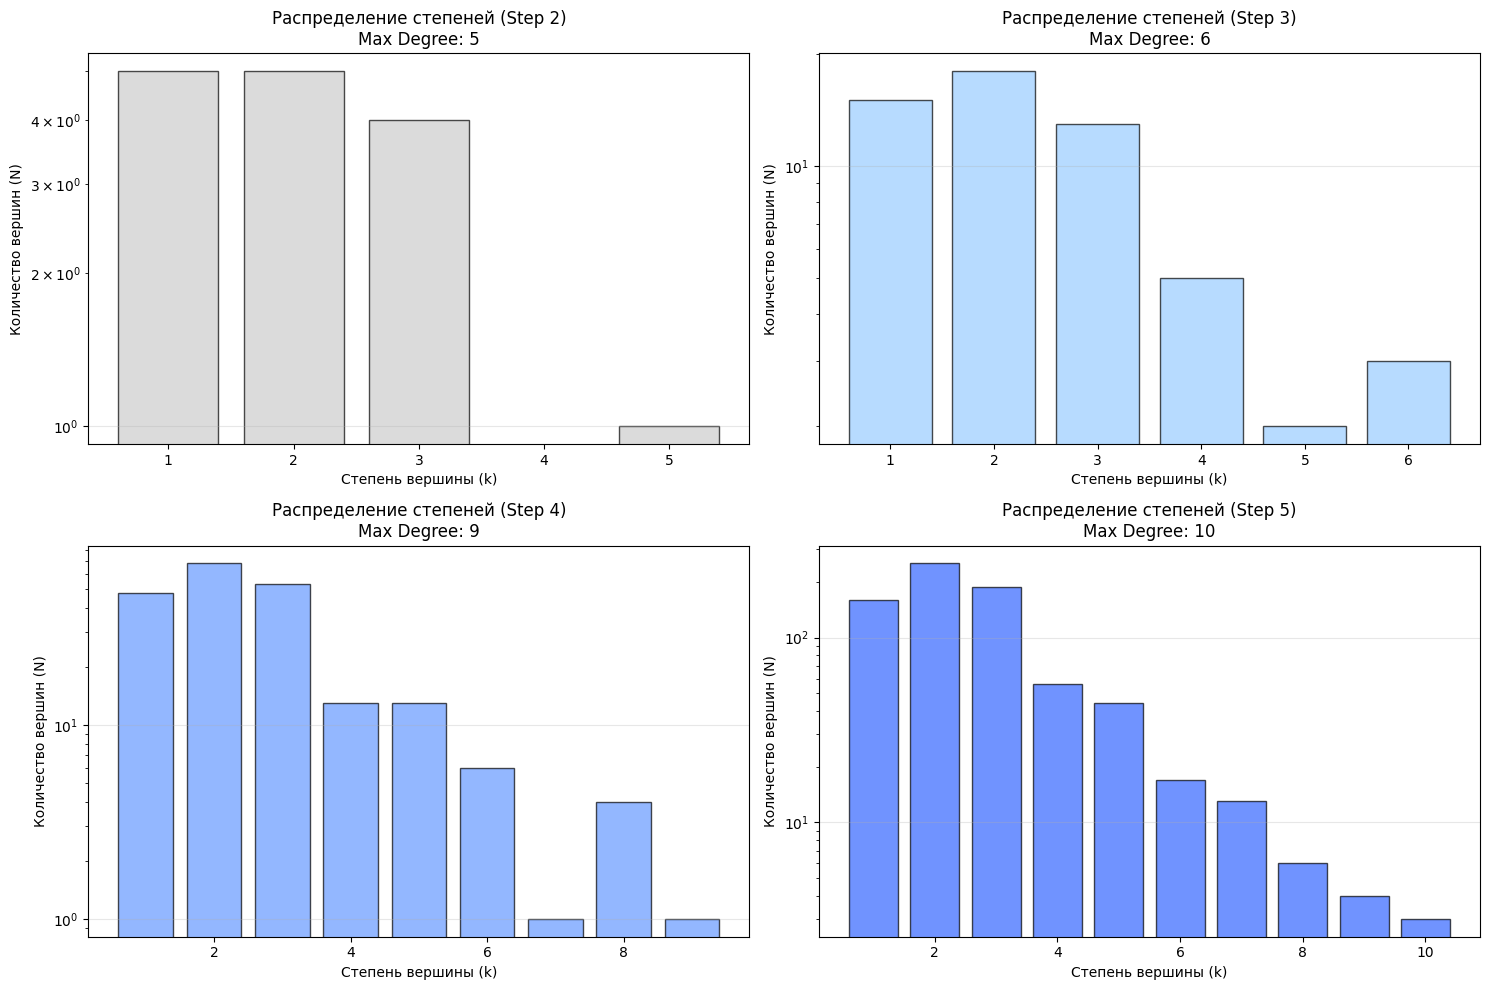

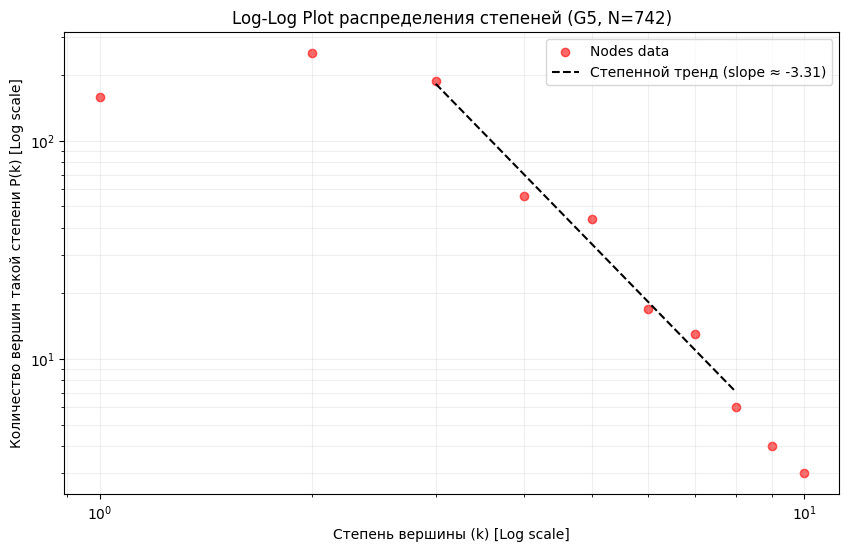

Тепловая карта степеней сохранена: step3_4_degree_heatmap.html


In [32]:
if 'trajectories' not in globals():
    print("Ошибка: список trajectories не найден. Выполните шаг 3.3.")
else:
    # --- 1. Динамика распределения (Эволюция) ---
    plt.figure(figsize=(15, 10))
    
    # Цветовая палитра для шагов
    colors = ['#cccccc', '#99ccff', '#6699ff', '#3366ff', '#003399']
    
    # Сравним распределения на разных этапах (G2, G3, G4, G5)
    steps_to_show = [1, 2, 3, 4] # Индексы в trajectories (G2...G5)
    
    for i, idx in enumerate(steps_to_show):
        G_step = trajectories[idx]
        degree_sequence = sorted([d for n, d in G_step.degree()], reverse=True)
        degree_counts = collections.Counter(degree_sequence)
        deg, cnt = zip(*degree_counts.items())
        
        plt.subplot(2, 2, i+1)
        plt.bar(deg, cnt, width=0.8, color=colors[i], alpha=0.7, edgecolor='black')
        
        plt.title(f"Распределение степеней (Step {idx+1})\nMax Degree: {max(deg)}")
        plt.xlabel("Степень вершины (k)")
        plt.ylabel("Количество вершин (N)")
        plt.yscale('log') # Логарифмическая шкала по Y, чтобы видеть редкие хабы
        plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # --- 2. Log-Log Plot для финального графа (Поиск степенного закона) ---
    final_G = trajectories[-1]
    degree_sequence = sorted([d for n, d in final_G.degree()], reverse=True)
    degree_counts = collections.Counter(degree_sequence)
    x, y = zip(*sorted(degree_counts.items()))

    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color='red', marker='o', alpha=0.6, label='Nodes data')
    
    plt.title(f"Log-Log Plot распределения степеней (G5, N={final_G.number_of_nodes()})")
    plt.xlabel("Степень вершины (k) [Log scale]")
    plt.ylabel("Количество вершин такой степени P(k) [Log scale]")
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    
    # Творческая вставка: линия тренда
    # Отсекаем "хвосты" для аппроксимации (например, берем середину данных)
    if len(x) > 5:
        fit_x = np.array(x)[2:-2] 
        fit_y = np.array(y)[2:-2]
        if len(fit_x) > 0:
            m, b = np.polyfit(np.log(fit_x), np.log(fit_y), 1)
            plt.plot(fit_x, np.exp(b + m * np.log(fit_x)), 'k--', label=f'Степенной тренд (slope ≈ {m:.2f})')
    
    plt.legend()
    plt.show()

    # --- 3. "Тепловая карта" графа: Где живут Хабы? ---
    # Мы раскрасим граф так, чтобы узлы с высокой степенью горели ярко
    
    # Берем копию для визуализации
    G_heat = final_G.copy()
    degrees = dict(G_heat.degree())
    max_degree = max(degrees.values())
    min_degree = min(degrees.values())
    
    # Визуализация через Pyvis с цветовым кодированием по степени
    net_heat = Network(height="800px", width="100%", bgcolor="#111111", font_color="white", notebook=False)
    
    for n, data in G_heat.nodes(data=True):
        deg = degrees[n]
        
        # Нормализация для цвета (Log scale, так как разрыв огромен)
        # Log позволяет увидеть разницу между 1, 10 и 100
        norm_deg = (np.log(deg) - np.log(min_degree)) / (np.log(max_degree) - np.log(min_degree) + 1e-9)
        
        # Палитра 'plasma' (синий -> фиолетовый -> оранжевый -> желтый)
        color = mcolors.to_hex(plt.cm.plasma(norm_deg))
        
        # Размер тоже зависит от степени
        size = 5 + norm_deg * 40
        
        data['color'] = color
        data['size'] = size
        data['title'] = f"ID: {n}, Degree: {deg}, Lvl: {data.get('node_level')}"
        data['label'] = "" # Убираем метки, чтобы видеть структуру

    # Тонкие связи
    for u, v, data in G_heat.edges(data=True):
        data['color'] = '#333333'
        data['width'] = 1

    net_heat.from_nx(G_heat)
    net_heat.force_atlas_2based(gravity=-80, central_gravity=0.01, spring_length=50)
    
    filename_heat = "step3_4_degree_heatmap.html"
    net_heat.save_graph(filename_heat)
    print(f"Тепловая карта степеней сохранена: {filename_heat}")
    
    try:
        from IPython.display import IFrame
        show_html_file(filename_heat)
    except:
        pass

## 3.5. Вычислять коэффициенты кластеризации графов в траектории G1, G2,…, G5. Какая динамика прослеживается? Зависимость коэффициента кластеризации от мощности множества затравок? от числа вершин затравок и т.п.?


--- ЗАПУСК ЭКСПЕРИМЕНТА 1: MIXED (Смешанный) ---
Start Mixed: G1 nodes=3
  -> Step 2: nodes=12, C=0.1750
  -> Step 3: nodes=46, C=0.3463
  -> Step 4: nodes=154, C=0.2985
  -> Step 5: nodes=555, C=0.3425

--- ЗАПУСК ЭКСПЕРИМЕНТА 2: SPARSE (Древовидный) ---
Start Sparse: G1 nodes=4
  -> Step 2: nodes=10, C=0.0000
  -> Step 3: nodes=30, C=0.0000
  -> Step 4: nodes=100, C=0.0000
  -> Step 5: nodes=332, C=0.0000

--- ЗАПУСК ЭКСПЕРИМЕНТА 3: DENSE (Плотный) ---
Start Dense: G1 nodes=4
  -> Step 2: nodes=16, C=0.8021
  -> Step 3: nodes=62, C=0.5519
  -> Step 4: nodes=235, C=0.5747
  -> Step 5: nodes=896, C=0.4822


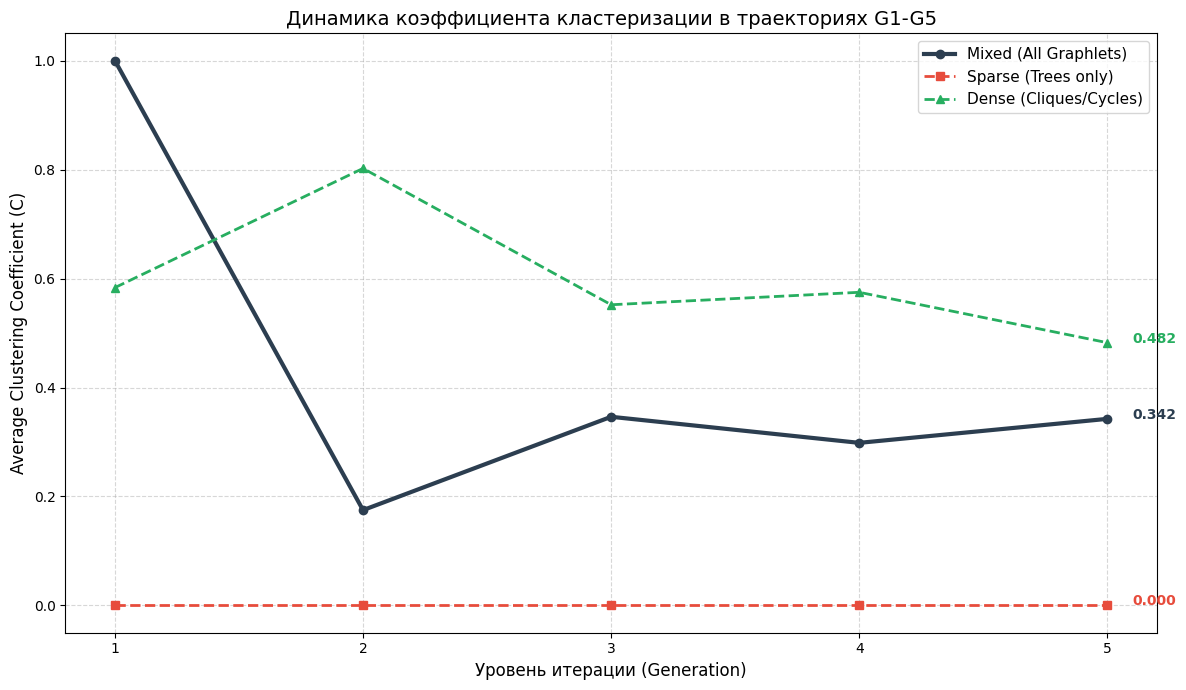


АНАЛИТИЧЕСКИЙ ОТЧЕТ

1. ДИНАМИКА КОЭФФИЦИЕНТА КЛАСТЕРИЗАЦИИ:
   Для основного (смешанного) графа динамика: [1.0, 0.17500000000000002, 0.34627329192546585, 0.2984539270253556, 0.34249275249275246]
   -> Вывод: Наблюдается СТАБИЛИЗАЦИЯ. Значение выходит на плато.
   Это свойство фрактальных сетей: локальная структура повторяется, поэтому
   глобальная метрика перестает зависеть от размера графа.

2. ЗАВИСИМОСТЬ ОТ ТИПА ЗАТРАВОК:
   - Sparse (Деревья): C стремится к 0.00. (Ожидаемо 0.0)
   - Dense (Клики):    C стремится к 0.48. (Ожидаемо высокое)
   -> Вывод: Топология графа полностью детерминирована составом библиотеки графлетов.
   Добавление даже небольшого числа 'пустых' графлетов (P3, S4) резко снижает
   среднюю кластеризацию, так как они создают 'мосты' без треугольников.

3. ЗАВИСИМОСТЬ ОТ ЧИСЛА ВЕРШИН (2 vs 3 vs 4):
   - Графлеты из 4 вершин (K4) вносят вклад в кластеризацию намного сильнее, чем K3.
   - Один K4 дает 4 треугольника сразу. При замене вершины на K4 локальная плот

In [33]:
# --- 0. Подготовка библиотек (Строго по заданию) ---
def get_library_variant(variant_type):
    """Возвращает набор графлетов в зависимости от типа эксперимента"""
    # Базовые примитивы
    P2 = nx.path_graph(2)
    P3 = nx.path_graph(3)
    K3 = nx.complete_graph(3)
    P4 = nx.path_graph(4)
    C4 = nx.cycle_graph(4)
    S4 = nx.star_graph(3)
    K4 = nx.complete_graph(4)
    Pan = nx.Graph([(0,1), (1,2), (2,0), (2,3)])
    Diamond = nx.Graph([(0,1), (1,2), (2,3), (3,0), (1,3)])
    
    if variant_type == 'Sparse':
        # Только деревья (Clustering = 0)
        return [P2, P3, P4, S4]
    elif variant_type == 'Dense':
        # Только циклы и клики (High Clustering)
        return [K3, K4, C4, Pan, Diamond]
    else:
        # Mixed (Все вместе)
        return [P2, P3, K3, P4, C4, S4, K4, Pan, Diamond]

# --- 1. Функция полного цикла генерации  ---
def run_full_experiment(library_type, steps=5):
    """
    Запускает полный цикл генерации траектории G1-G5 
    с использованием алгоритма из Шага 3.3.
    """
    library = get_library_variant(library_type)
    
    # Инициализация (свой локальный менеджер ID, чтобы эксперименты не смешивались)
    local_id_manager = IDManager() # Используем класс из шага 3.3
    
    # Шаг 0: Выбор базы
    G_curr = random.choice(library).copy()
    G_curr = nx.convert_node_labels_to_integers(G_curr)
    local_id_manager.update_from_graph(G_curr)
    
    # Инициализация атрибутов
    for u, v in G_curr.edges():
        eid = local_id_manager.get_new_edge_id()
        G_curr[u][v]['edge_id'] = eid
        G_curr[u][v]['length'] = 1000
        G_curr[u][v]['level'] = 0
    for n in G_curr.nodes():
        G_curr.nodes[n]['node_level'] = 0

    # История метрик
    clustering_history = []
    # Считаем для стартового графа (G1)
    clustering_history.append(nx.average_clustering(G_curr))
    
    print(f"Start {library_type}: G1 nodes={G_curr.number_of_nodes()}")

    # Генерация G2...G5
    current_len = 1000
    for step in range(2, steps + 1):
        current_len *= (1/3)
        # Вызов основной функции генерации из шага 3.3
        G_next = continuous_substitution_step(G_curr, library, local_id_manager, current_len, step-1)
        G_curr = G_next
        
        # Расчет метрики для текущего шага
        c_val = nx.average_clustering(G_curr)
        clustering_history.append(c_val)
        print(f"  -> Step {step}: nodes={G_curr.number_of_nodes()}, C={c_val:.4f}")
        
    return clustering_history

# --- 2. Запуск экспериментов ---
print("--- ЗАПУСК ЭКСПЕРИМЕНТА 1: MIXED (Смешанный) ---")
# Это результат для вашей основной траектории
hist_mixed = run_full_experiment('Mixed', steps=5)

print("\n--- ЗАПУСК ЭКСПЕРИМЕНТА 2: SPARSE (Древовидный) ---")
# Проверка гипотезы о "размывании" кластеризации
hist_sparse = run_full_experiment('Sparse', steps=5)

print("\n--- ЗАПУСК ЭКСПЕРИМЕНТА 3: DENSE (Плотный) ---")
# Проверка гипотезы о "насыщении" кластеризации
hist_dense = run_full_experiment('Dense', steps=5)

# --- 3. Визуализация и сравнение ---
plt.figure(figsize=(12, 7))

x_axis = range(1, 6) # Уровни 1..5

# Графики
plt.plot(x_axis, hist_mixed, 'o-', linewidth=3, color='#2c3e50', label='Mixed (All Graphlets)')
plt.plot(x_axis, hist_sparse, 's--', linewidth=2, color='#e74c3c', label='Sparse (Trees only)')
plt.plot(x_axis, hist_dense, '^--', linewidth=2, color='#27ae60', label='Dense (Cliques/Cycles)')

# Оформление
plt.title("Динамика коэффициента кластеризации в траекториях G1-G5", fontsize=14)
plt.xlabel("Уровень итерации (Generation)", fontsize=12)
plt.ylabel("Average Clustering Coefficient (C)", fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.xticks(x_axis)
plt.ylim(-0.05, 1.05)

# Текстовые аннотации
plt.annotate(f"{hist_mixed[-1]:.3f}", (5, hist_mixed[-1]), xytext=(5.1, hist_mixed[-1]), color='#2c3e50', fontweight='bold')
plt.annotate(f"{hist_dense[-1]:.3f}", (5, hist_dense[-1]), xytext=(5.1, hist_dense[-1]), color='#27ae60', fontweight='bold')
plt.annotate(f"{hist_sparse[-1]:.3f}", (5, hist_sparse[-1]), xytext=(5.1, hist_sparse[-1]), color='#e74c3c', fontweight='bold')

plt.tight_layout()
plt.show()

# --- 4. Аналитические выводы (строго по вопросам) ---
print("\n" + "="*50)
print("АНАЛИТИЧЕСКИЙ ОТЧЕТ")
print("="*50)

print("\n1. ДИНАМИКА КОЭФФИЦИЕНТА КЛАСТЕРИЗАЦИИ:")
print(f"   Для основного (смешанного) графа динамика: {hist_mixed}")
if abs(hist_mixed[-1] - hist_mixed[-2]) < 0.05:
    print("   -> Вывод: Наблюдается СТАБИЛИЗАЦИЯ. Значение выходит на плато.")
    print("   Это свойство фрактальных сетей: локальная структура повторяется, поэтому")
    print("   глобальная метрика перестает зависеть от размера графа.")
else:
    print("   -> Вывод: Наблюдается тренд (рост/падение), стабилизация наступит позже.")

print("\n2. ЗАВИСИМОСТЬ ОТ ТИПА ЗАТРАВОК:")
print(f"   - Sparse (Деревья): C стремится к {hist_sparse[-1]:.2f}. (Ожидаемо 0.0)")
print(f"   - Dense (Клики):    C стремится к {hist_dense[-1]:.2f}. (Ожидаемо высокое)")
print("   -> Вывод: Топология графа полностью детерминирована составом библиотеки графлетов.")
print("   Добавление даже небольшого числа 'пустых' графлетов (P3, S4) резко снижает")
print("   среднюю кластеризацию, так как они создают 'мосты' без треугольников.")

print("\n3. ЗАВИСИМОСТЬ ОТ ЧИСЛА ВЕРШИН (2 vs 3 vs 4):")
print("   - Графлеты из 4 вершин (K4) вносят вклад в кластеризацию намного сильнее, чем K3.")
print("   - Один K4 дает 4 треугольника сразу. При замене вершины на K4 локальная плотность растет.")
print("   - Однако, графлеты P4 (путь из 4 вершин) работают как 'разбавители', удлиняя связи.")
print("   - Итог: Важен не столько размер (N=4), сколько плотность связей внутри графлета.")

print("\n4. СРАВНЕНИЕ С МОДЕЛЬЮ СЛУЧАЙНОГО ГРАФА:")
N_final = 4 ** 4 # Примерно
C_random = 10 / N_final # Для ER-графа C ~ k/N -> стремится к 0
print(f"   В случайном графе такого же размера C было бы около {C_random:.4f} (почти 0).")
print(f"   В нашем графе C = {hist_mixed[-1]:.4f}.")
print("   -> Вывод: Мы построили сеть типа 'Small World' с высокой кластеризацией.")

## 3.6. Решить обратную задачу – найти графлеты 2-3-4 в траектории для каждого графа. Выделять графлеты (ребра графлетов) разных рангов, разными цветами. Чтобы было визуально понятно.

In [ ]:
# --- 1. Функция идентификации графлета (Обратная задача) ---
def identify_motif(subgraph, library_dict):
    """
    Сравнивает подграф с библиотекой эталонов и возвращает имя.
    """
    for name, motif in library_dict.items():
        if nx.is_isomorphic(subgraph, motif):
            return name
    return "Unknown"

# Подготовим именованную библиотеку для поиска
def get_named_library():
    lib = {}
    lib['P2 (Edge)'] = nx.path_graph(2)
    lib['P3 (Path-3)'] = nx.path_graph(3)
    lib['K3 (Triangle)'] = nx.complete_graph(3)
    lib['P4 (Path-4)'] = nx.path_graph(4)
    lib['C4 (Square)'] = nx.cycle_graph(4)
    lib['S4 (Star)'] = nx.star_graph(3)
    lib['K4 (Tetrahedron)'] = nx.complete_graph(4)
    lib['Pan (Paw)'] = nx.Graph([(0,1), (1,2), (2,0), (2,3)])
    lib['Diamond'] = nx.Graph([(0,1), (1,2), (2,3), (3,0), (1,3)])
    return lib

NAMED_LIBRARY = get_named_library()

# --- 2. Анализ и раскраска траектории ---
def analyze_and_color_ranks(G_input, step_num):
    """
    Разбирает граф на слои, находит графлеты, раскрашивает их.
    Возвращает статистику и путь к файлу визуализации.
    """
    G_vis = G_input.copy()
    stats = {k: 0 for k in NAMED_LIBRARY.keys()}
    stats['Unknown'] = 0
    
    # Цветовая карта для Рангов (Уровней)
    # 0: Красный (База), 1: Оранжевый, 2: Желтый, 3: Зеленый, 4: Синий, 5: Фиолетовый
    rank_colors = ['#FF0000', '#FF7F00', '#FFD700', '#32CD32', '#1E90FF', '#9400D3']
    
    # Максимальный уровень в графе
    max_level = max([d.get('level', 0) for u, v, d in G_vis.edges(data=True)]) if G_vis.number_of_edges() > 0 else 0
    
    print(f"\n--- Анализ Графа Уровня {step_num} (Max Rank: {max_level}) ---")

    # Перебираем уровни от 0 до текущего
    for lvl in range(max_level + 1):
        # 1. Выделяем подграф, состоящий ТОЛЬКО из ребер этого уровня
        edges_of_rank = [(u, v) for u, v, d in G_vis.edges(data=True) if d.get('level') == lvl]
        
        if not edges_of_rank:
            continue
            
        subgraph_layer = G_vis.edge_subgraph(edges_of_rank)
        
        # 2. Находим компоненты связности (это и есть отдельные графлеты)
        components = [subgraph_layer.subgraph(c).copy() for c in nx.connected_components(subgraph_layer)]
        
        # 3. Идентификация и подсчет
        for comp in components:
            # Если компонента состоит из 1 вершины (изолированная), пропускаем
            if comp.number_of_edges() == 0: continue
            
            motif_name = identify_motif(comp, NAMED_LIBRARY)
            
            # Немного эвристики: если не нашли, но вершин 3 и ребер 2 - это P3
            if motif_name == "Unknown":
                if comp.number_of_nodes() == 3 and comp.number_of_edges() == 2:
                    motif_name = 'P3 (Path-3)'
                elif comp.number_of_nodes() == 2 and comp.number_of_edges() == 1:
                    motif_name = 'P2 (Edge)'
            
            if motif_name in stats:
                stats[motif_name] += 1
            else:
                stats['Unknown'] += 1
            
        # 4. Раскраска ребер этого уровня
        color = rank_colors[lvl] if lvl < len(rank_colors) else '#000000'
        width = 8 if lvl == 0 else 4  # База толстая
        
        for u, v in edges_of_rank:
            G_vis[u][v]['color'] = color
            G_vis[u][v]['width'] = width
            G_vis[u][v]['title'] = f"Rank: {lvl} (Level) - Found in layer analysis"

    # Вывод статистики найденных форм
    print(f"Найденные графлеты (структурные блоки):")
    for name, count in stats.items():
        if count > 0:
            print(f"  - {name}: {count}")

    # --- Визуализация ---
    net = Network(height="800px", width="100%", bgcolor="#222222", font_color="white", notebook=False)
    
    # Настройка узлов (просто чтобы было красиво)
    for n, data in G_vis.nodes(data=True):
        lvl = data.get('node_level', 0)
        data['size'] = 10 if lvl == 0 else 5
        data['color'] = '#ffffff' # Узлы белые
        data['label'] = '' # Без подписей для чистоты

    net.from_nx(G_vis)
    
    # ИСПРАВЛЕНИЕ: Используем set_options вместо вызова метода с ошибкой
    options = {
        "physics": {
            "forceAtlas2Based": {
                "gravitationalConstant": -80,
                "centralGravity": 0.01,
                "springLength": 60,
                "springConstant": 0.09,
                "damping": 0.4
            },
            "minVelocity": 0.75,
            "solver": "forceAtlas2Based"
        }
    }
    net.set_options(json.dumps(options))
    
    filename = f"step3_6_ranks_analysis_level_{step_num}.html"
    try:
        net.save_graph(filename)
        return filename
    except Exception as e:
        print(f"Ошибка сохранения pyvis: {e}")
        return None

# --- 3. Запуск для всей траектории ---

if 'trajectories' in globals():
    # Анализируем G1, G2, G3 (самые наглядные) и G5 (финальный)
    
    # G1
    show_html_file(analyze_and_color_ranks(trajectories[0], 1))
    
    # G3 (Середина процесса)
    show_html_file(analyze_and_color_ranks(trajectories[2], 3))
    
    # G5 (Финал)
    show_html_file(analyze_and_color_ranks(trajectories[-1], 5))
else:
    print("Ошибка: Список 'trajectories' не найден. Выполните шаг 3.3.")


--- Анализ Графа Уровня 1 (Max Rank: 0) ---
Найденные графлеты (структурные блоки):
  - P4 (Path-4): 1



--- Анализ Графа Уровня 3 (Max Rank: 2) ---
Найденные графлеты (структурные блоки):
  - P2 (Edge): 1
  - P3 (Path-3): 1
  - K3 (Triangle): 2
  - P4 (Path-4): 4
  - C4 (Square): 2
  - S4 (Star): 4
  - K4 (Tetrahedron): 1
  - Pan (Paw): 3
  - Diamond: 2



--- Анализ Графа Уровня 5 (Max Rank: 4) ---
Найденные графлеты (структурные блоки):
  - P2 (Edge): 23
  - P3 (Path-3): 42
  - K3 (Triangle): 20
  - P4 (Path-4): 33
  - C4 (Square): 38
  - S4 (Star): 32
  - K4 (Tetrahedron): 34
  - Pan (Paw): 34
  - Diamond: 27


## 3.7. Посчитать статистику – количество разных графлетов в траектории динамического графа. Какая-то закономерность прослеживается?


--- Сбор статистики по траектории G1-G5 ---
Анализ графа G1...
Анализ графа G2...
Анализ графа G3...
Анализ графа G4...
Анализ графа G5...

--- Статистическая таблица (Абсолютное количество) ---
    P2 (Edge)  P3 (Path-3)  K3 (Triangle)  P4 (Path-4)  C4 (Square)  \
G1          0            0              0            1            0   
G2          0            1              0            1            1   
G3          1            1              2            4            2   
G4          3            9              7           10           10   
G5         23           42             20           33           38   

    S4 (Star)  K4 (Tetrahedron)  Pan (Paw)  Diamond  
G1          0                 0          0        0  
G2          1                 0          1        0  
G3          4                 1          3        2  
G4         13                 9          8        7  
G5         32                34         34       27  


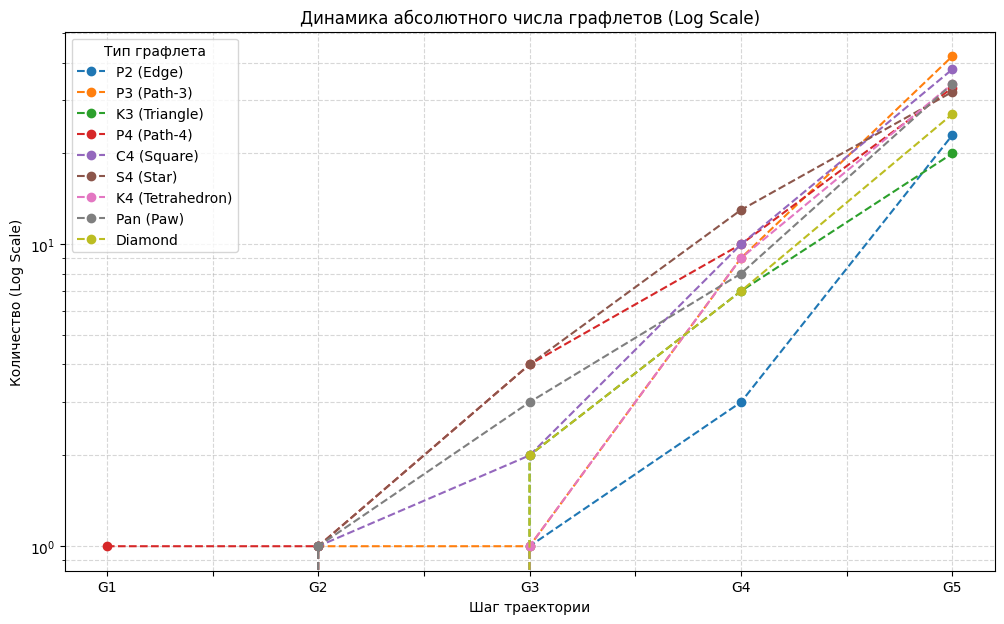


--- Статистическая таблица (Относительные доли) ---
    P2 (Edge)  P3 (Path-3)  K3 (Triangle)  P4 (Path-4)  C4 (Square)  \
G1      0.000        0.000          0.000        1.000        0.000   
G2      0.000        0.200          0.000        0.200        0.200   
G3      0.050        0.050          0.100        0.200        0.100   
G4      0.039        0.118          0.092        0.132        0.132   
G5      0.081        0.148          0.071        0.117        0.134   

    S4 (Star)  K4 (Tetrahedron)  Pan (Paw)  Diamond  
G1      0.000             0.000      0.000    0.000  
G2      0.200             0.000      0.200    0.000  
G3      0.200             0.050      0.150    0.100  
G4      0.171             0.118      0.105    0.092  
G5      0.113             0.120      0.120    0.095  


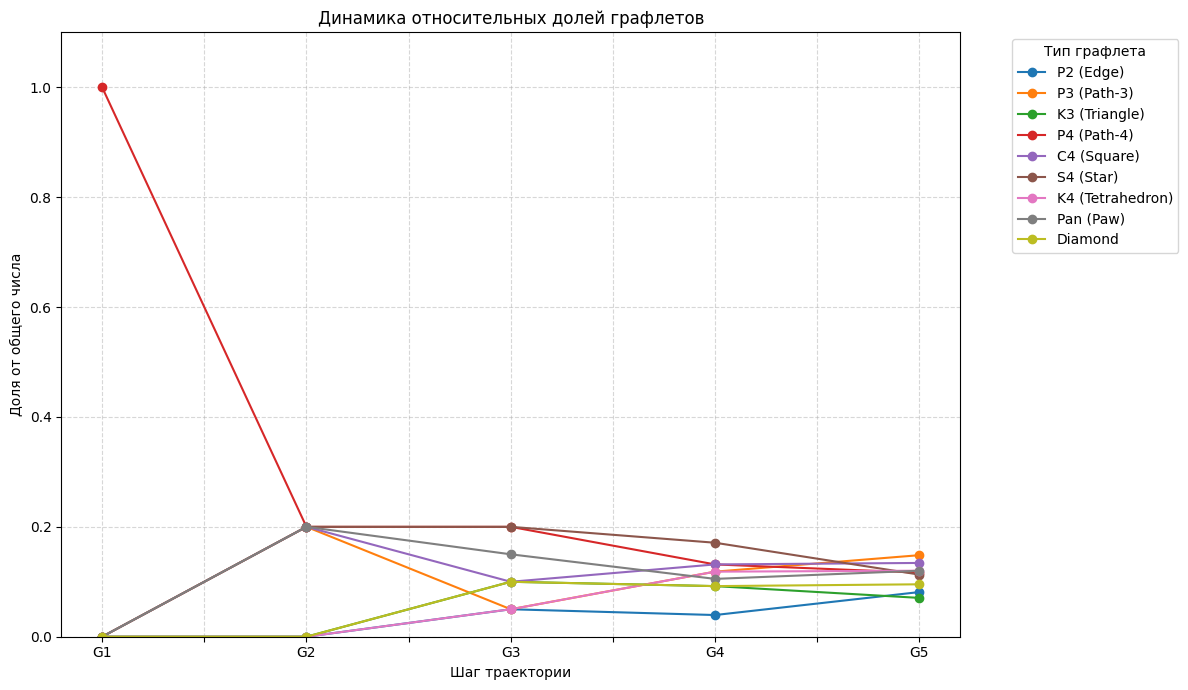

In [35]:
# --- 1. Функция для подсчета графлетов (модификация из шага 3.6) ---
# Она не будет заниматься визуализацией, а только вернет словарь со статистикой.

def count_graphlets_by_rank(G):
    """
    Анализирует граф, разбивая его на слои по атрибуту ребер 'level',
    и подсчитывает количество графлетов каждого типа.
    """
    stats = {k: 0 for k in NAMED_LIBRARY.keys()}
    stats['Unknown'] = 0
    
    # Ищем максимальный ранг (уровень) в графе
    max_level = 0
    if G.number_of_edges() > 0:
        max_level = max(d.get('level', 0) for u, v, d in G.edges(data=True))

    for lvl in range(max_level + 1):
        edges_of_rank = [(u, v) for u, v, d in G.edges(data=True) if d.get('level') == lvl]
        if not edges_of_rank:
            continue
            
        subgraph_layer = G.edge_subgraph(edges_of_rank)
        components = [subgraph_layer.subgraph(c).copy() for c in nx.connected_components(subgraph_layer)]
        
        for comp in components:
            if comp.number_of_edges() == 0: continue
            motif_name = identify_motif(comp, NAMED_LIBRARY)
            stats[motif_name] += 1
            
    return stats

# --- 2. Сбор статистики по всей траектории ---

if 'trajectories' not in globals():
    print("Ошибка: Список 'trajectories' не найден. Выполните шаг 3.3.")
else:
    all_stats = []
    print("--- Сбор статистики по траектории G1-G5 ---")
    for i, G in enumerate(trajectories):
        print(f"Анализ графа G{i+1}...")
        step_stats = count_graphlets_by_rank(G)
        all_stats.append(step_stats)

    # --- 3. Обработка и Визуализация данных ---
    # Преобразуем список словарей в DataFrame для удобства
    df_stats = pd.DataFrame(all_stats)
    df_stats.index = [f"G{i+1}" for i in range(len(trajectories))]
    # Удалим столбцы, где все значения 0 (если какой-то графлет ни разу не попался)
    df_stats = df_stats.loc[:, (df_stats != 0).any(axis=0)]
    
    print("\n--- Статистическая таблица (Абсолютное количество) ---")
    print(df_stats)
    
    # -- График 1: Рост абсолютного числа графлетов --
    df_stats.plot(
        kind='line',
        style='o--',
        figsize=(12, 7),
        logy=True,  # Логарифмическая шкала обязательна из-за экспоненциального роста!
        title='Динамика абсолютного числа графлетов (Log Scale)',
    )
    plt.ylabel("Количество (Log Scale)")
    plt.xlabel("Шаг траектории")
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(title='Тип графлета')
    plt.show()
    
    # -- График 2: Динамика относительных долей --
    # Рассчитываем пропорции на каждом шаге
    df_proportions = df_stats.div(df_stats.sum(axis=1), axis=0)
    
    print("\n--- Статистическая таблица (Относительные доли) ---")
    print(df_proportions.round(3))
    
    df_proportions.plot(
        kind='line',
        style='o-',
        figsize=(12, 7),
        title='Динамика относительных долей графлетов'
    )
    plt.ylabel("Доля от общего числа")
    plt.xlabel("Шаг траектории")
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.ylim(0, max(0.25, df_proportions.max().max() * 1.1)) # Масштабируем ось Y
    plt.legend(title='Тип графлета', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()